In [1]:
%load_ext autoreload
%autoreload 2

## Data curation

Curating raw data with the enhanced chat client

In [2]:
import os

import dotenv

dotenv.load_dotenv()

DATA_DIR = os.getenv("DATA_DIR")

In [3]:
import glob
import json
import os

import pandas as pd

data = pd.read_json("../../data/curation_v1/perturbations/tahoe.json")

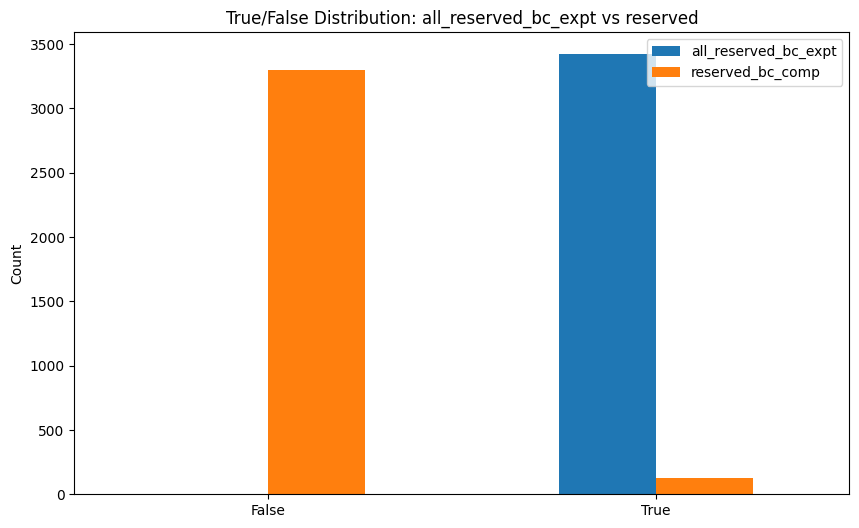

In [4]:
# Using seaborn for even simpler plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Combine both columns for comparison
combined_data = pd.DataFrame(
    {
        "all_reserved_bc_expt": data["reserved_bc_cell_line"].value_counts(),
        "reserved_bc_comp": data["reserved_bc_comp"].value_counts(),
    }
).fillna(0)

combined_data.plot(kind="bar", ax=ax)
plt.title("True/False Distribution: all_reserved_bc_expt vs reserved")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [5]:
data

,context,perturbations,reserved_bc_cell_line,reserved_bc_comp
0,"[{'cell type': 'PANC-1', 'description': 'The s...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
1,"[{'cell type': 'PANC-1', 'description': 'The s...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
2,"[{'cell type': 'A549', 'description': 'The sou...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
3,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
4,"[{'cell type': 'A549', 'description': 'The sou...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
...,...,...,...,...
3415,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
3416,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
3417,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False
3418,"[{'cell type': 'A549', 'description': 'The sou...","[{'perturbation type': 'chemical', 'smiles': '...",True,False


In [29]:
import yaml
from explain.eval.tools.chem.chembl import ChEMBLResolver
resolver = ChEMBLResolver(cache_path=None)


In [ ]:

def process_input(row):
    data_dict = {}
    data_dict["context"] = row["context"][0]
    data_dict["perturbations"] = row["perturbations"]
    return data_dict

def extract_smiles(perturbation):
    smiles = [x.get("smiles") for x in perturbation]
    return [x for x in smiles if x is not None]

data["inputs"] = data.apply(process_input, axis=1)
data["smiles"] = data["perturbations"].apply(extract_smiles)


In [32]:
from explain.eval.tools.chem._utils import _compute_inchikey

unique_smiles = data.smiles.explode().dropna().unique()
tahoe_smiles = pd.DataFrame()
tahoe_smiles["smiles"] = unique_smiles

tahoe_smiles["inchi_key"] = tahoe_smiles["smiles"].apply(_compute_inchikey)


def get_names(smiles):

    names = []
    output = resolver._tool_logic(resolver.args_schema(smiles=smiles))
    try:
        names = [output[1].get("name")] + output[1].get("synonyms", [])
    except Exception:
        pass
    return list(filter(None, names))

tahoe_smiles["names"] = tahoe_smiles["smiles"].apply(get_names)



[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Rule applied: Sulfoxide to -S+(O-)-
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:23] Running Normalizer
[14:22:23] Initializing Normalizer
[14:22:2

In [8]:
aboutamol = pd.read_parquet("../../data/curation_v1/perturbations/aboutamol.parquet")

In [34]:
filtered_aboutamol = aboutamol[(aboutamol.inchi_key.isin(tahoe_smiles.inchi_key)) & (aboutamol.less_than_10um == True)]


In [57]:
from collections import defaultdict

import numpy as np
import pandas as pd

# Potency direction sets
LOWER_IS_BETTER = {"IC50", "EC50", "Ki", "Kd"}
HIGHER_IS_BETTER = {"pIC50", "pEC50", "pKi", "pKd"}


def _ascending_for_mt(mt: str) -> bool:
    """True if lower values mean more potent."""
    return str(mt) in LOWER_IS_BETTER


def _targets_list(t):
    if pd.isna(t) or t is None:
        return []
    return [x.strip() for x in str(t).replace("|", ";").split(";") if x.strip()]


def _rank_score_row(mt, vmin, vmax):
    """Higher score = more potent (for sorting descending)."""
    if _ascending_for_mt(mt):
        return -float(vmin)  # lower is better
    return float(vmax)  # higher is better for pX


def _diverse_round_robin(ordered_df, target_col="mce_target", k=10):
    """Round-robin selection to ensure target diversity."""
    buckets = defaultdict(list)
    for i, t in enumerate(ordered_df[target_col].tolist()):
        toks = _targets_list(t)
        buckets[toks[0] if toks else "__unknown__"].append(i)
    picks, keys = [], list(buckets.keys())
    while len(picks) < min(k, len(ordered_df)):
        advanced = False
        for bk in keys:
            if buckets[bk]:
                picks.append(buckets[bk].pop(0))
                advanced = True
                if len(picks) >= k:
                    break
        if not advanced:
            break
    if len(picks) < min(k, len(ordered_df)):
        for i in range(len(ordered_df)):
            if i not in picks:
                picks.append(i)
            if len(picks) >= k:
                break
    return ordered_df.iloc[picks].reset_index(drop=True)


def _pick_top_with_priority(groups_df: pd.DataFrame, k: int = 10) -> pd.DataFrame:
    """Priority: human+gene > human(no gene) > other species; then diverse & potent."""
    if groups_df.empty:
        return groups_df

    def _order(df):
        return df.sort_values("rank_score", ascending=False, kind="mergesort").reset_index(drop=True)

    b1 = groups_df[
        (groups_df["bioref_organism"] == "Homo sapiens")
        & groups_df["bioref_gene_name"].notna()
        & (groups_df["bioref_gene_name"] != "")
    ]
    b2 = groups_df[
        (groups_df["bioref_organism"] == "Homo sapiens")
        & ~((groups_df["bioref_gene_name"].notna()) & (groups_df["bioref_gene_name"] != ""))
    ]
    b3 = groups_df[groups_df["bioref_organism"] != "Homo sapiens"]

    out, remain = [], k
    for bucket in (_order(b1), _order(b2), _order(b3)):
        if remain <= 0 or bucket.empty:
            continue
        part = _diverse_round_robin(bucket, k=remain)
        out.append(part)
        remain -= len(part)

    return pd.concat(out, ignore_index=True) if out else groups_df.iloc[0:0]


def _collect_sources(df_sub: pd.DataFrame, mt: str):
    """
    Keep only `source` and `publication_doi`, at most 5 entries.
    Selection based on top potency (lowest for IC50/etc., highest for pIC50/etc.).
    """
    cols = ["bioref_source_name", "bioref_article_doi", "bioref_std_measurement_value"]
    have = [c for c in cols if c in df_sub.columns]
    if not have:
        return []

    asc = _ascending_for_mt(mt)
    df_sorted = df_sub.sort_values("bioref_std_measurement_value", ascending=asc, na_position="last")

    seen, out = set(), []
    for _, r in df_sorted.iterrows():
        item = {
            "source": r.get("bioref_source_name"),
            "publication_doi": r.get("bioref_article_doi"),
        }
        key = (item["source"], item["publication_doi"])
        if key not in seen:
            seen.add(key)
            out.append(item)
        if len(out) >= 5:
            break
    return out


def build_pertubation_bioactivities(row):
    """Return compact JSON with aggregated bioactivities and top sources."""
    # ---- synonyms ----
    all_names = row.get("names", [])
    best_name = all_names[0] if len(all_names)>0 else None
    extra = all_names[1:] if len(all_names)>1 else []
    extra = [x for x in extra if x!=best_name]
    synonym_names = [best_name]
    if len(extra) > 0:
        k = min(3, len(extra))
        synonym_names.extend(np.random.choice(extra, size=k, replace=False).tolist())
    synonym_names = [x for x in sorted(set(synonym_names)) if x is not None]

    # ---- fetch activities ----
    tmp_act = filtered_aboutamol[filtered_aboutamol["inchi_key"] == row["inchi_key"]].copy()

    # drop unused
    tmp_act = tmp_act.drop(
        columns=[
            c
            for c in [
                "bioref_original_measurement_value",
                "general_kce",
                "less_than_10um",
                "mce_vendor_id",
                "bioref_original_measurement_unit",
            ]
            if c in tmp_act.columns
        ],
        errors="ignore",
    )

    # ensure required cols
    for c in [
        "mce_target",
        "bioref_gene_name",
        "bioref_organism",
        "bioref_measurement_type",
        "bioref_std_measurement_value",
        "bioref_std_measurement_unit",
        "bioref_source_name",
        "bioref_article_doi",
    ]:
        if c not in tmp_act.columns:
            tmp_act[c] = pd.NA

    # numeric std only
    tmp_act["bioref_std_measurement_value"] = pd.to_numeric(tmp_act["bioref_std_measurement_value"], errors="coerce")
    tmp_act = tmp_act.dropna(subset=["bioref_std_measurement_value"]).copy()
    if tmp_act.empty:
        return json.dumps(
            {
                "synonym_names": synonym_names,
                "smiles": row["smiles"],
                "inchi_key": row["inchi_key"],
                "bioactivities": {"info": {}, "aggregates": []},
            },
            separators=(",", ":"),
        )

    # ---- hoist mce_* info ----
    info = {}
    for f in [
        "mce_product_name",
        "mce_clinical_phase",
        "mce_research_area",
        "mce_pathway",
        "mce_biological_activity",
        "mce_target",
    ]:
        if f in tmp_act.columns:
            vals = [v for v in tmp_act[f].dropna().unique().tolist() if v not in (None, "", "null")]
            if len(vals) == 1:
                info[f] = vals[0]
            elif len(vals) > 1:
                info[f] = " | ".join(sorted(map(str, vals)))

    # ---- aggregate by (target, org, type, unit, gene) ----
    gb = tmp_act.groupby(
        ["mce_target", "bioref_organism", "bioref_measurement_type", "bioref_std_measurement_unit", "bioref_gene_name"],
        dropna=False,
        as_index=False,
    ).agg(
        count=("bioref_std_measurement_value", "size"),
        min=("bioref_std_measurement_value", "min"),
        median=("bioref_std_measurement_value", "median"),
        max=("bioref_std_measurement_value", "max"),
    )

    gb["rank_score"] = [
        _rank_score_row(mt if pd.notna(mt) else "IC50", vmin, vmax)
        for mt, vmin, vmax in zip(gb["bioref_measurement_type"], gb["min"], gb["max"], strict=False)
    ]

    gb_sel = _pick_top_with_priority(gb)

    # ---- build aggregates ----
    aggregates = []
    for _, r in gb_sel.iterrows():
        mask = (
            (tmp_act["mce_target"] == r["mce_target"])
            & (tmp_act["bioref_organism"] == r["bioref_organism"])
            & (tmp_act["bioref_measurement_type"] == r["bioref_measurement_type"])
            & (tmp_act["bioref_std_measurement_unit"] == r["bioref_std_measurement_unit"])
            & (
                tmp_act["bioref_gene_name"].fillna("")
                == (r["bioref_gene_name"] if pd.notna(r["bioref_gene_name"]) else "")
            )
        )
        srcs = _collect_sources(tmp_act.loc[mask], r["bioref_measurement_type"])

        entry = {
            "gene": r["bioref_gene_name"] if pd.notna(r["bioref_gene_name"]) else None,
            "organism": r["bioref_organism"],
            "type": r["bioref_measurement_type"],
            "unit": r["bioref_std_measurement_unit"],
            "sources": srcs,
        }
        if int(r["count"]) == 1:
            entry["value"] = float(r["min"])
        else:
            entry["min"] = float(r["min"])
            entry["median"] = float(r["median"])
            entry["max"] = float(r["max"])
        aggregates.append(entry)

    return json.dumps(
        {
            "synonym_names": synonym_names,
            "smiles": row["smiles"],
            "inchi_key": row["inchi_key"],
            "bioactivities": {"info": info, "aggregates": aggregates},
        },
        separators=(",", ":"),
    )

In [58]:
tahoe_smiles["bioactivities"] = tahoe_smiles.apply(build_pertubation_bioactivities, axis=1)

In [60]:
tahoe_smiles

,smiles,inchi_key,names,bioactivities
0,CC(C)CC(C(=O)O)NC(=O)C(C(CC1=CC=CC=C1)N)O.Cl,VGGGPCQERPFHOB-UHFFFAOYSA-N,[],"{""synonym_names"":[],""smiles"":""CC(C)CC(C(=O)O)N..."
1,C1=CC=C(C(=C1)C2=NC(=NO2)C3=CC(=CC=C3)C(=O)O)F,OOUGLTULBSNHNF-UHFFFAOYSA-N,"[ATALUREN, ATALUREN, ATALURENO, PTC-124, PTC12...","{""synonym_names"":[""ATALUREN"",""ATALURENO"",""PTC-..."
2,CC1=C(C=C(C=C1)[C@H]2[C@@H]([C@H]([C@@H]([C@H]...,GLYQZIOQAGAOCL-RONUNVLDSA-N,[],"{""synonym_names"":[],""smiles"":""CC1=C(C=C(C=C1)[..."
3,C1CN=C(N1)NC2=C(C3=NC=CN=C3C=C2)Br,XYLJNLCSTIOKRM-UHFFFAOYSA-N,"[BRIMONIDINE, AGN-190342 FREE BASE, BRIMONIDIN...","{""synonym_names"":[""AGN-190342 FREE BASE"",""BRIM..."
4,C1CC1C(=O)NC2=NN3C(=N2)C=CC=C3C4=CC=C(C=C4)CN5...,RIJLVEAXPNLDTC-UHFFFAOYSA-N,"[FILGOTINIB, FILGOTINIB, G-146034, G146034, GL...","{""synonym_names"":[""FILGOTINIB"",""G146034"",""GLPG..."
...,...,...,...,...
368,CC#CC1(CCC2C1(CC(C3=C4CCC(=O)C=C4CCC23)C5=CC=C...,VKHAHZOOUSRJNA-UHFFFAOYSA-N,[],"{""synonym_names"":[],""smiles"":""CC#CC1(CCC2C1(CC..."
369,CNC(=O)C1=C(C=C(C=C1)N2C(=S)N(C(=O)C23CCC3)C4=...,HJBWBFZLDZWPHF-UHFFFAOYSA-N,"[APALUTAMIDE, APALUTAMIDA, APALUTAMIDE, ARN-50...","{""synonym_names"":[""APALUTAMIDA"",""APALUTAMIDE"",..."
370,C1=CC(=C(C=C1[N+](=O)[O-])Cl)NC(=O)C2=C(C=CC(=...,XYCDHXSQODHSLG-UHFFFAOYSA-N,[],"{""synonym_names"":[],""smiles"":""C1=CC(=C(C=C1[N+..."
371,CC(=CCCC(=CCCC(=CC=CC(=CC(=O)O)C)C)C)C,UUBHZHZSIKRVIV-UHFFFAOYSA-N,[],"{""synonym_names"":[],""smiles"":""CC(=CCCC(=CCCC(=..."


In [62]:
from explain.llm import LLMClient, LLMConfig

config = LLMConfig(
    provider="gemini",
    model="gemini-2.5-flash",
)

client = LLMClient(config)

2025-08-15 15:11:02.794 | INFO     | explain.llm._client:__init__:298 - Initialized Google Gemini client with model gemini-2.5-flash
2025-08-15 15:11:02.795 | INFO     | explain.llm._client:__init__:699 - Initialized unified LLM client with provider: gemini


In [63]:
import json
import asyncio
import tqdm
import pandas as pd
from pathlib import Path


# Cell 4: Fast processing functions without type hints
def create_bioactivity_prompt(bioactivity_json, template):
    """Create a prompt for bioactivity summarization using the template."""
    return template.replace("{bioactivity_json}", bioactivity_json)


async def generate_bioactivity_summary(client, bioactivity_data, template, semaphore):
    """Generate a bioactivity summary for a single molecule."""
    async with semaphore:
        try:
            prompt = create_bioactivity_prompt(bioactivity_data, template)
            messages = [{"role": "user", "content": prompt}]
            response = await client.agenerate(messages)
            return response.content.strip()
        except Exception as e:
            print(f"Error generating summary: {e}")
            return f"Error generating summary: {str(e)}"


async def process_molecules_batch(client, molecules_batch, template, semaphore, batch_id, checkpoint_dir, pbar=None):
    """Process a batch of molecules and generate summaries with real-time progress."""
    batch_file = checkpoint_dir / f"summary_batch_{batch_id:04d}.json"

    # Check if this batch was already processed
    if batch_file.exists():
        if pbar:
            pbar.update(len(molecules_batch))
        return []  # Return empty since we're not reloading existing results

    try:
        batch_results = []

        for _idx, row in molecules_batch.iterrows():
            # Generate summary for this molecule's bioactivity data
            summary = await generate_bioactivity_summary(client, row["bioactivities"], template, semaphore)

            # Extract synonym names directly without parsing JSON again
            result = {
                "smiles": row["smiles"],
                "inchi_key": row.get("inchi_key"),
                "bioactivity_summary": summary,
                "original_bioactivities": row["bioactivities"],
            }
            batch_results.append(result)

            # Update progress bar immediately after each molecule
            if pbar:
                pbar.update(1)

        # Save batch result immediately
        with open(batch_file, "w") as f:
            json.dump(batch_results, f, indent=2)

        return batch_results

    except Exception as e:
        print(f"Batch {batch_id} processing failed: {e}")
        if pbar:
            pbar.update(len(molecules_batch))
        return []


def create_batches(df, batch_size=5):
    """Create batches of molecules for processing."""
    batches = []
    for i in range(0, len(df), batch_size):
        batches.append(df.iloc[i : i + batch_size])
    return batches


def count_existing_results(checkpoint_dir):
    """Fast count of existing results without loading all JSON."""
    if not checkpoint_dir.exists():
        return 0

    batch_files = list(checkpoint_dir.glob("summary_batch_*.json"))
    return len(batch_files)


async def process_bioactivity_summaries(
    client,
    df,
    template,
    batch_size=3,
    max_batches=None,
    max_concurrent=3,
    checkpoint_dir="../../data/curation_v1/perturbations/tahoe_bioactivity_summaries",
):
    """Process molecules with real-time progress updates"""

    checkpoint_path = Path(checkpoint_dir)
    checkpoint_path.mkdir(parents=True, exist_ok=True)

    # Fast check for existing results
    existing_batch_count = count_existing_results(checkpoint_path)
    if existing_batch_count > 0:
        print(f"Found {existing_batch_count} existing batch files")

    # Create all batches upfront
    all_batches = create_batches(df, batch_size)
    if max_batches:
        all_batches = all_batches[:max_batches]

    # Skip already processed batches
    remaining_batches = all_batches[existing_batch_count:]

    if len(remaining_batches) == 0:
        print("All batches already processed!")
        return pd.DataFrame()  # Return empty for now, can load results later if needed

    total_molecules = sum(len(batch) for batch in remaining_batches)
    print(f"Processing {len(remaining_batches)} new batches ({total_molecules} molecules)")

    # Process batches one by one for real-time updates
    semaphore = asyncio.Semaphore(max_concurrent)
    all_results = []

    semaphore = asyncio.Semaphore(max_concurrent)

    # Create all tasks at once
    tasks = [
        process_molecules_batch(client, batch, template, semaphore, existing_batch_count + i, checkpoint_path)
        for i, batch in enumerate(remaining_batches)
    ]

    # Run all tasks concurrently with progress tracking
    all_results = []
    batch_results = await tqdm.gather(*tasks, desc="Processing batches")
    for results in batch_results:
        all_results.extend(results)

    print(f"\nProcessed {len(remaining_batches)} new batches")
    print(f"New results: {len(all_results)} molecules")

    return pd.DataFrame(all_results)


def load_all_results_when_needed(base_glob="../../data/curation_v1/perturbations/bioactivity_summaries*/"):
    """Load all results from multiple subdirectories only when explicitly requested."""
    all_results = []
    subdirs = sorted(Path().glob(base_glob))

    for subdir in subdirs:
        batch_files = sorted(subdir.glob("summary_batch_*.json"))
        print(f"Loading {len(batch_files)} batch files from {subdir}...")
        for batch_file in tqdm(batch_files, desc=f"Loading batches from {subdir}"):
            try:
                with open(batch_file) as f:
                    batch_results = json.load(f)
                    all_results.extend(batch_results)
            except Exception as e:
                print(f"Error loading {batch_file}: {e}")

    return pd.DataFrame(all_results)

In [64]:
from tqdm.auto import tqdm

# Run the processing (start with a small test batch)
template = Path("../../data/curation_v1/templates/bioassay-to-report.txt").read_text()
results_df = await process_bioactivity_summaries(
    client=client,
    df=tahoe_smiles,
    template=template,
    batch_size=10,
    max_batches=None,
    max_concurrent=30,
    checkpoint_dir=f"../../data/curation_v1/perturbations/bioactivity_summaries_tahoe",
)

/Users/emmanuel.noutahi/Code/hooke-explain/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing 38 new batches (373 molecules)


Processing batches: 100%|██████████| 38/38 [02:03<00:00,  3.26s/it]


Processed 38 new batches
New results: 373 molecules


In [66]:
results_df

,smiles,inchi_key,bioactivity_summary,original_bioactivities
0,CC(C)CC(C(=O)O)NC(=O)C(C(CC1=CC=CC=C1)N)O.Cl,VGGGPCQERPFHOB-UHFFFAOYSA-N,"The unnamed compound, identified by InChIKey V...","{""synonym_names"":[],""smiles"":""CC(C)CC(C(=O)O)N..."
1,C1=CC=C(C(=C1)C2=NC(=NO2)C3=CC(=CC=C3)C(=O)O)F,OOUGLTULBSNHNF-UHFFFAOYSA-N,Ataluren (InChIKey: OOUGLTULBSNHNF-UHFFFAOYSA-...,"{""synonym_names"":[""ATALUREN"",""ATALURENO"",""PTC-..."
2,CC1=C(C=C(C=C1)[C@H]2[C@@H]([C@H]([C@@H]([C@H]...,GLYQZIOQAGAOCL-RONUNVLDSA-N,The compound with InChIKey GLYQZIOQAGAOCL-RONU...,"{""synonym_names"":[],""smiles"":""CC1=C(C=C(C=C1)[..."
3,C1CN=C(N1)NC2=C(C3=NC=CN=C3C=C2)Br,XYLJNLCSTIOKRM-UHFFFAOYSA-N,Brimonidine (InChIKey: XYLJNLCSTIOKRM-UHFFFAOY...,"{""synonym_names"":[""AGN-190342 FREE BASE"",""BRIM..."
4,C1CC1C(=O)NC2=NN3C(=N2)C=CC=C3C4=CC=C(C=C4)CN5...,RIJLVEAXPNLDTC-UHFFFAOYSA-N,Filgotinib (InChIKey: RIJLVEAXPNLDTC-UHFFFAOYS...,"{""synonym_names"":[""FILGOTINIB"",""G146034"",""GLPG..."
...,...,...,...,...
368,CC#CC1(CCC2C1(CC(C3=C4CCC(=O)C=C4CCC23)C5=CC=C...,VKHAHZOOUSRJNA-UHFFFAOYSA-N,"The compound, identified by InChIKey VKHAHZOOU...","{""synonym_names"":[],""smiles"":""CC#CC1(CCC2C1(CC..."
369,CNC(=O)C1=C(C=C(C=C1)N2C(=S)N(C(=O)C23CCC3)C4=...,HJBWBFZLDZWPHF-UHFFFAOYSA-N,"Apalutamide (synonyms: APALUTAMIDA, ARN-509, J...","{""synonym_names"":[""APALUTAMIDA"",""APALUTAMIDE"",..."
370,C1=CC(=C(C=C1[N+](=O)[O-])Cl)NC(=O)C2=C(C=CC(=...,XYCDHXSQODHSLG-UHFFFAOYSA-N,The compound with InChIKey XYCDHXSQODHSLG-UHFF...,"{""synonym_names"":[],""smiles"":""C1=CC(=C(C=C1[N+..."
371,CC(=CCCC(=CCCC(=CC=CC(=CC(=O)O)C)C)C)C,UUBHZHZSIKRVIV-UHFFFAOYSA-N,The compound with SMILES `CC(=CCCC(=CCCC(=CC=C...,"{""synonym_names"":[],""smiles"":""CC(=CCCC(=CCCC(=..."


In [67]:
data

,context,perturbations,reserved_bc_cell_line,reserved_bc_comp,inputs,smiles
0,"[{'cell type': 'PANC-1', 'description': 'The s...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'PANC-1', 'descripti...",[CC(C)CC(C(=O)O)NC(=O)C(C(CC1=CC=CC=C1)N)O.Cl]
1,"[{'cell type': 'PANC-1', 'description': 'The s...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'PANC-1', 'descripti...",[CC(C)CC(C(=O)O)NC(=O)C(C(CC1=CC=CC=C1)N)O.Cl]
2,"[{'cell type': 'A549', 'description': 'The sou...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'A549', 'description...",[CC(C)CC(C(=O)O)NC(=O)C(C(CC1=CC=CC=C1)N)O.Cl]
3,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'HepG2/C3A', 'descri...",[CC(C)CC(C(=O)O)NC(=O)C(C(CC1=CC=CC=C1)N)O.Cl]
4,"[{'cell type': 'A549', 'description': 'The sou...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'A549', 'description...",[C1=CC=C(C(=C1)C2=NC(=NO2)C3=CC(=CC=C3)C(=O)O)F]
...,...,...,...,...,...,...
3415,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'HepG2/C3A', 'descri...",[CCCCN1CCCCC1C(=O)NC2=C(C=CC=C2C)C.Cl]
3416,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'HepG2/C3A', 'descri...",[C1CCNC(C1)C2(CN(C2)C(=O)C3=C(C(=C(C=C3)F)F)NC...
3417,"[{'cell type': 'HepG2/C3A', 'description': 'Th...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'HepG2/C3A', 'descri...",[CNC(=O)C1=C(C=C(C=C1)N2C(=S)N(C(=O)C23CCC3)C4...
3418,"[{'cell type': 'A549', 'description': 'The sou...","[{'perturbation type': 'chemical', 'smiles': '...",True,False,"{'context': {'cell type': 'A549', 'description...",[CCN(CC)CCNC(=O)C1=CC=C(C=C1)N.Cl]


In [68]:
def build_inputs(row):
    """
    Build inputs for the LLM.
    """
    pertubation = json.dumps(row["inputs"])
    annot_mols = results_df[results_df["smiles"].isin(row["smiles"])]
    prior_info = "\n---\n".join(annot_mols["bioactivity_summary"].tolist())
    if prior_info:
        prior_info = f"Here is what we know about some of the perturbations already.\n{prior_info}"
    return dict(prior_knowledge_if_any=prior_info, treatment=pertubation)
data["prompt"] = data.apply(build_inputs, axis=1)

In [70]:
print(data.prompt.iloc[0])

{'prior_knowledge_if_any': 'Here is what we know about some of the perturbations already.\nThe unnamed compound, identified by InChIKey VGGGPCQERPFHOB-UHFFFAOYSA-N and SMILES CC(C)CC(C(=O)O)NC(=O)C(C(CC1=CC=CC=C1)N)O.Cl, exhibits inhibitory activity against multiple targets.\n\nIt demonstrates inhibition of Aminopeptidase N (ANPEP) with IC50 values of 3500 nM in *Homo sapiens* and a range of 3600-8500 nM in *Sus scrofa*. The compound also inhibits Leukotriene A4 Hydrolase (LTA4H) with an IC50 of 500 nM. Additionally, a Ki value of 20 nM was reported for an unspecified target in *Sus scrofa*.\n\nSpecific biological activities, detailed target proteins beyond gene names, associated pathways, research areas, or clinical phases are not provided in the available data. All reported activities are derived from various assays.', 'treatment': '{"context": {"cell type": "PANC-1", "description": "The source organ of cell line PANC-1 is Pancreas. The key driver mutations of this cell line are list

In [ ]:
results_df.rename(columns={"original_bioactivities": "bioactivities"}).to_parquet("/Users/emmanuel.noutahi/Code/hooke-explain/data/curation_v1/perturbations/tahoe_smiles.parquet")

In [78]:
data.to_parquet("/Users/emmanuel.noutahi/Code/hooke-explain/data/curation_v1/perturbations/tahoe_perturbations.parquet")